# Data Pipelines & Data Analytics Lifecycle
# Forecasting the Wind Power Production in Orkney

## Introduction

In this assignment you will play the role of a Data Scientist consultant for the Scottish and Southern Electricity Networks (SSEN). Among many other areas, the SSEN provides electricity for the Okrney islands, in Northern Scottland. This archipelago has significant wind and marine energy resources, and it generates over 100% of its 
net power from renewable sources, coming mainly from wind turbines situated across Orkney. This is good news for Orkney and the environment, but although wind farms provide emissions-free energy, they only generate electricity when the wind blows.

Your job? To design and implement a training pipeline, including data preprocessing, evaluation and model storing, for a small wind energy forecasting system. The goal here is to use weather forecasting data to predict the energy production for Orkney. You will need all your data scientist skills for insights, and you will have 
some libraries at your disposal, such as Scikit-Learn and MLFlow (and as many others as you might need). This Jupyter Notebook will help you started.

The steps you will complete in this project are:

- align the datasets
- create pipelines for preprocessing and prediction
- compare your pipelines with MLflow Tracking
- register your best model with MLflow Registry
- serve the best model
- package the project using MLProjects

Above this cell you will find an *Outline* button. Click it and an outline of this notebook should appear on the left bottom corner of the screen. This will help you navigate to a specific section.

**Dependencies**

If you've just created this workspace, install mlflow by typing the command below in the Terminal. If you already did this in a previous session, there is no need to install it again.

```
pip install mlflow
```

Now let's import all libraries necessary for this project.
The first time you will run a cell in this notebook, a dialogue box will appear asking if you want to Install/enable suggested extentions: python and jupyter. Go ahead and once that is finished select the created kernel.

In [1]:
import mlflow

# You will probably need these
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline

# This are for example purposes. You may discard them if you don't use them.
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from mlflow.models import infer_signature
from urllib.parse import urlparse

### TODO -> HERE YOU CAN ADD ANY OTHER LIBRARIES YOU MAY NEED ###

<a name="data"></a> 

## Data exploration

You will work with three datasets:

**Power generation data** (`power.csv`)

* *Source:* Scottish and Southern Electricity Networks (SSEN)
* *Granularity:* 1-minute sampling
* *Target variable:* Total renewable power generation (MW)

Key fields:

* `time`: Timestamp of measurement
* `Total`: Renewable power generation (MW)

**Weather forecast data** (`weather.csv`)

* *Source:* UK Met Office
* *Granularity:* 3-hour intervals
* Forecasts include a *source time* (forecast creation) and a *target time* (forecasted timestamp)

Key fields:

* `time`: Target time of the forecast
* `Speed`: Wind speed (m/s)
* `Direction`: Wind direction (categorical string, e.g. "NW")
* `Source_time`: Forecast generation time
* `Lead_hours`: Forecast horizon

**Future forecasts** (`future.csv`)

* Weather forecasts to be used for generating future power predictions using your model

Let's first load the first 2 datasets.

In [2]:
power = pd.read_csv('data/power.csv', parse_dates=["time"], index_col="time")
wind = pd.read_csv('data/weather.csv', parse_dates=["time"], index_col="time")

In [3]:
power.shape

(109026, 3)

In [4]:
wind.shape

(716, 4)

In [5]:
merged = pd.merge_asof(power, wind, on='time', allow_exact_matches=True)
merged_df = merged.dropna()
merged_df = merged_df.drop(columns=['ANM','Non-ANM','Lead_hours','Source_time'])
merged_df.head()

,time,Total,Direction,Speed
81,2021-12-11 15:00:00+00:00,27.864560,SSE,11.176
82,2021-12-11 15:01:00+00:00,28.489561,SSE,11.176
83,2021-12-11 15:02:00+00:00,28.150561,SSE,11.176
84,2021-12-11 15:03:00+00:00,26.634557,SSE,11.176
85,2021-12-11 15:04:00+00:00,26.172559,SSE,11.176


Let's take a look at the resulting dataframes:

In [4]:
power.head()

,ANM,Non-ANM,Total
time,,,
2021-12-11 13:39:00+00:00,10.195558,17.102,27.297558
2021-12-11 13:40:00+00:00,10.043559,17.582,27.625559
2021-12-11 13:41:00+00:00,10.961558,17.139,28.100558
2021-12-11 13:42:00+00:00,11.240559,16.194,27.434559
2021-12-11 13:43:00+00:00,10.672559,16.566,27.238559


This table contains three columns, but closer inspection will reveal a clear relationship between those three. Can you spot that?

We are interested in the total power generation, regardless of the source type. Modify the table such that only the column of interest is kept.

In [4]:
### TODO -> REMOVE UNNECESSARY COLUMNS ###
power_df = power.copy()
power_df.drop(columns=['ANM', 'Non-ANM'], axis = 1, inplace= True)
power_df.head()

,Total
time,
2021-12-11 13:39:00+00:00,27.297558
2021-12-11 13:40:00+00:00,27.625559
2021-12-11 13:41:00+00:00,28.100558
2021-12-11 13:42:00+00:00,27.434559
2021-12-11 13:43:00+00:00,27.238559


In [6]:
wind.head()

,Direction,Lead_hours,Source_time,Speed
time,,,,
2021-12-11 15:00:00+00:00,SSE,1,1639227600,11.17600
2021-12-11 18:00:00+00:00,SSW,1,1639238400,8.04672
2021-12-11 21:00:00+00:00,WSW,1,1639249200,11.17600
2021-12-12 00:00:00+00:00,WSW,1,1639260000,8.94080
2021-12-12 03:00:00+00:00,SW,1,1639270800,9.83488


This table contains four columns, but lead hours and source time are irrelevant here. Can you think why?

It also contains a column named Direction, which shows the cardinal direction that the wind is blowing from. For example, the record containing ’SW’ in the wind direction field would indicate that the wind is blowing from the South-West (and to
the North-East). Since our models can only handle numeric data, you will need to perform some transformation on this feature later on.

Look at the table's index. Do both data sources contain the same intervals? And if not, what problems could arise when merging the data?

In [7]:
wind_df = wind.copy()
wind_df.drop(columns=['Lead_hours', 'Source_time'], axis=1, inplace=True)

In [8]:
wind_df.head()

,Direction,Speed
time,,
2021-12-11 15:00:00+00:00,SSE,11.17600
2021-12-11 18:00:00+00:00,SSW,8.04672
2021-12-11 21:00:00+00:00,WSW,11.17600
2021-12-12 00:00:00+00:00,WSW,8.94080
2021-12-12 03:00:00+00:00,SW,9.83488


Source time: when the prediction was made<br>
Lead hours: how far into the feature the model is predicting<br>
Time: the future moment the model is predicting<br>

These three are correlated, they will create multicolinearity in the model if we include all three which could cause model fitting issues.<br>
time = Source_time + Lead_hours

The power_df is recorded minutely and wind_df every 3 hours it seems so.

### Data alignment
We have two dataframes, one with weather forecasts and one with power generation. To do some analysis on the relationship between these two datasets, it might be useful to align the datasets.

**Example**

In [9]:
# Joining the data
joined_dfs = power_df.join(wind_df, how="inner")
joined_dfs.shape

(610, 3)

In [10]:
joined_dfs.head()

,Total,Direction,Speed
time,,,
2021-12-11 15:00:00+00:00,27.864560,SSE,11.17600
2021-12-11 18:00:00+00:00,26.091558,SSW,8.04672
2021-12-11 21:00:00+00:00,16.727561,WSW,11.17600
2021-12-12 00:00:00+00:00,21.364559,WSW,8.94080
2021-12-12 03:00:00+00:00,21.231557,SW,9.83488


Joining the two datasets with an inner join means keeping only those records that match their index. Although this will work, you may notice that most of our data is discarded due to the unmatching time intervals. You may want to explore other possible ways to merge the data; you can argue for using a specific method or experiment with both later on. For now, try out a different way to align the datasets.

In [11]:
### TODO -> JOIN THE TWO DATASETS ###
merged = pd.merge_asof(power_df, wind_df, on='time', allow_exact_matches=True)

In [12]:
merged

,time,Total,Direction,Speed
0,2021-12-11 13:39:00+00:00,27.297558,NaN,NaN
1,2021-12-11 13:40:00+00:00,27.625559,NaN,NaN
2,2021-12-11 13:41:00+00:00,28.100558,NaN,NaN
3,2021-12-11 13:42:00+00:00,27.434559,NaN,NaN
4,2021-12-11 13:43:00+00:00,27.238559,NaN,NaN
...,...,...,...,...
109021,2022-03-11 13:34:00+00:00,33.405000,SE,13.85824
109022,2022-03-11 13:35:00+00:00,33.418000,SE,13.85824
109023,2022-03-11 13:36:00+00:00,33.305998,SE,13.85824
109024,2022-03-11 13:37:00+00:00,33.184999,SE,13.85824


Options:
- Left join
- Forward/backward fill
- Match nearest observation

### Understanding the data: EDA

It can be also useful to plot our datasets to see what relationships they might hold.

Text(0.5, 1.0, 'Speed and Power per Direction')

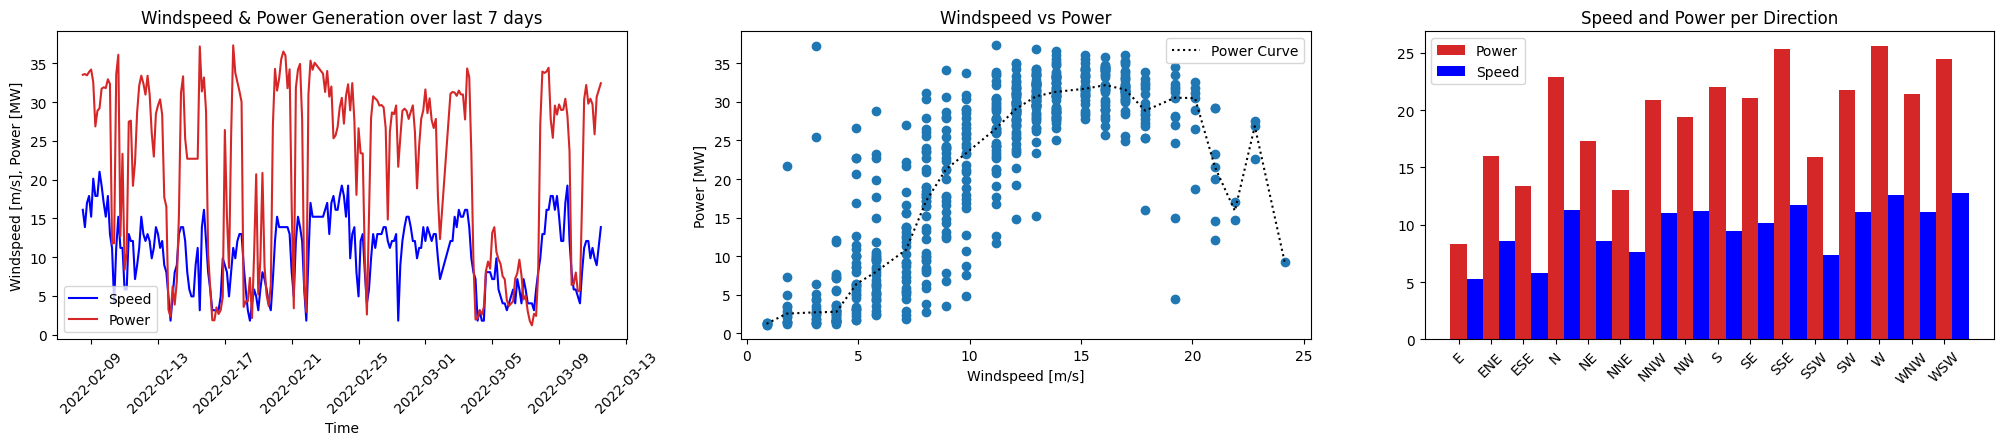

In [13]:
# Subplots
fig, ax = plt.subplots(1,3, figsize=(25,4))

# Speed and Power for the last 7 days
ax[0].plot(joined_dfs["Speed"].tail(int(30*24/3)), label="Speed", color="blue") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].plot(joined_dfs["Total"].tail(int(30*24/3)), label="Power", color="tab:red") # Since the datasets are joined every three hours, we need the last 7 days times 24 hours diveded by 3 hours
ax[0].set_title("Windspeed & Power Generation over last 7 days")
ax[0].set_xlabel("Time")
ax[0].tick_params(axis='x', labelrotation = 45)
ax[0].set_ylabel("Windspeed [m/s], Power [MW]")
ax[0].legend()

# Speed vs Total (Power Curve nature)
ax[1].scatter(joined_dfs["Speed"], joined_dfs["Total"])
power_curve = joined_dfs.groupby("Speed").median(numeric_only=True)["Total"]
ax[1].plot(power_curve.index, power_curve.values, "k:", label="Power Curve")
ax[1].legend()
ax[1].set_title("Windspeed vs Power")
ax[1].set_ylabel("Power [MW]")
ax[1].set_xlabel("Windspeed [m/s]")

# Speed and Power per Wind Direction
wind_grouped_by_direction = joined_dfs.groupby("Direction").mean(numeric_only=True).reset_index()
bar_width = 0.5
x = np.arange(len(wind_grouped_by_direction.index))

ax[2].bar(x, wind_grouped_by_direction.Total, width=0.5, label="Power", color="tab:red")
ax[2].bar(x + bar_width, wind_grouped_by_direction.Speed, width=0.5, label="Speed", color="blue")
ax[2].legend()
ax[2].set_xticks(x)
ax[2].set_xticklabels(wind_grouped_by_direction.Direction)
ax[2].tick_params(axis='x', labelrotation = 45)
ax[2].set_title("Speed and Power per Direction")

1. Identifying non linearity: speed and power are not in a linear relationship. (see power curve)
2. All the data between hours are discarded since one dataset is minute based and the other hour based.
3. Wind direction is porbably a significant feature since different directions have a distinct average power.

These plots should already give us an intuition of the different relationships between features. There is a clear relationship between the wind speed and the power generation from the turbines. But that relationship is not completely linear. Which plot shows that? Finally, it seems like the power generation also depends of where the wind is coming from. Maybe this could also be a useful feature.

In order to plot the relationship between wind speed and power generation we have performed a very simple join with the two datasets. But since the intervals are not the same, a lot of data is discarded (can you spot where in the code this happens?). 

Text(0.5, 0, 'Windspeed [m/s]')

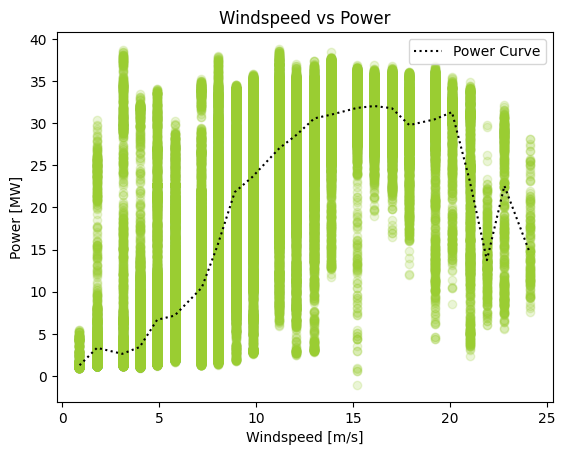

In [57]:
joined_dfs = merged.dropna().copy()

# Speed vs Total (Power Curve nature)
joined_dfs["speed_bin"] = joined_dfs["Speed"].round(1)
power_curve = joined_dfs.groupby("speed_bin")["Total"].median()

plt.scatter(joined_dfs["Speed"], joined_dfs["Total"], color = 'yellowgreen', alpha=0.2)
#power_curve = joined_dfs.groupby("Speed").median(numeric_only=True)["Total"]
plt.plot(power_curve.index, power_curve.values, "k:", label="Power Curve")
plt.legend()
plt.title("Windspeed vs Power")
plt.ylabel("Power [MW]")
plt.xlabel("Windspeed [m/s]")

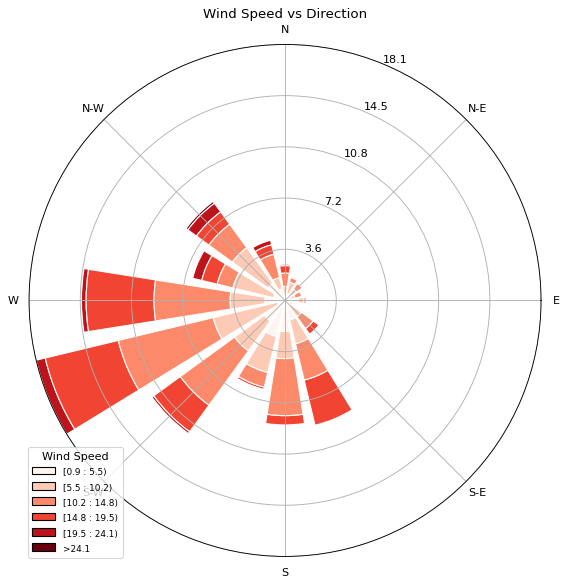

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

df = joined_dfs.copy()

df["Direction"] = df["Direction"].astype(str).str.strip().str.upper()

# Compass mapping
compass = {
    "N":0, "NNE":22.5, "NE":45, "ENE":67.5,
    "E":90, "ESE":112.5, "SE":135, "SSE":157.5,
    "S":180, "SSW":202.5, "SW":225, "WSW":247.5,
    "W":270, "WNW":292.5, "NW":315, "NNW":337.5
}

df["deg"] = df["Direction"].map(compass)
df["deg"] = df["deg"].fillna(pd.to_numeric(df["Direction"], errors="coerce"))

df["speed"] = pd.to_numeric(df["Speed"], errors="coerce")

df = df.dropna(subset=["deg", "speed"])

ax = WindroseAxes.from_ax()

ax.bar(
    df["deg"],
    df["speed"],
    normed=True,
    opening=0.8,
    edgecolor="white",
    cmap = plt.cm.Reds
)

ax.set_legend(title="Wind Speed")
plt.title("Wind Speed vs Direction")

plt.show()

In [15]:
joined_dfs['time']

81       2021-12-11 15:00:00+00:00
82       2021-12-11 15:01:00+00:00
83       2021-12-11 15:02:00+00:00
84       2021-12-11 15:03:00+00:00
85       2021-12-11 15:04:00+00:00
                    ...           
109021   2022-03-11 13:34:00+00:00
109022   2022-03-11 13:35:00+00:00
109023   2022-03-11 13:36:00+00:00
109024   2022-03-11 13:37:00+00:00
109025   2022-03-11 13:38:00+00:00
Name: time, Length: 108945, dtype: datetime64[ns, UTC]

## Pipeline and data transformations

Now that we have our data, we need to construct the pipeline to process this data and pass it to our Machine Learning model. For this, use the Pipeline class from Scikit-Learn.

This class applies a list of transformations to your data, and pass the final state to an estimator (your model). Intermediate steps of the pipeline must be ‘transforms’, that is, they must implement fit and transform methods. The final estimator only needs to implement fit.

You can find more information about Scikit-Learn's Pipeline [here](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).

**Example**

In [7]:
### TODO -> CREATE YOUR OWN PIPELINE ###
# Create your pipeline with the desired transformers
from sklearn.preprocessing import OneHotEncoder
pipeline = Pipeline([
    ("Linear Regression", LinearRegression())
])

### Evaluate your model

Now that you have a preprocessing pipeline ready, along with the final estimator, you may want to know how well your model performs. Choose the method you prefer, with special attention to the selected metric.

**Example**

In [18]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Select our feature variables and our target variable.
merged_df = merged.dropna()
#merged_df["Lag"] = merged_df["Speed"].shift()

def select_best_lag(time_series, max_lag):
    aic_values = []
    
    # .values removes the 'unsupported' index and treats it as a simple list of numbers
    data = time_series.values 
    
    for p in range(1, max_lag + 1):
        # We use data instead of time_series
        model = ARIMA(data, order=(p, 0, 0))  
        model_fit = model.fit()
        aic_values.append((p, model_fit.aic))
        
    return aic_values

# Set max_lag to try and get the best lag based on AIC
max_lag = 10
aic_scores = select_best_lag(merged_df["Total"], max_lag)

# Find the lag with the minimum AIC value
best_lag = min(aic_scores, key=lambda x: x[1])[0]
print(f'\nOptimal Lag based on AIC: {best_lag}')


Optimal Lag based on AIC: 9


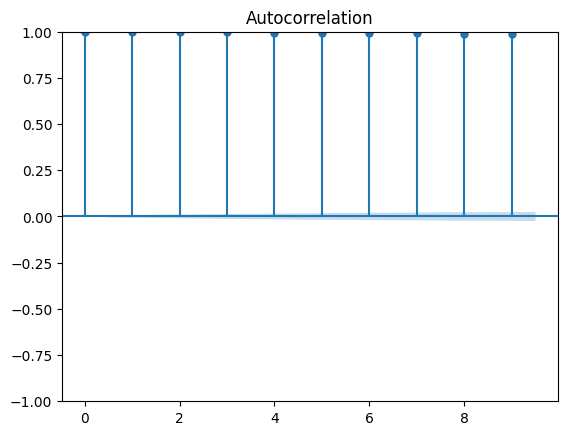

In [20]:
plot_acf(merged_df["Total"], lags=best_lag)
plt.show()

In [23]:
merged_df = merged.dropna().copy()
merged_df['Lag'] = merged_df['Total'].shift(best_lag)
X = merged_df[["Speed", "Direction", "Lag"]]
y = merged_df["Total"]

In [ ]:

# Split the data so we can test how well our model performs in unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 

#one hot encode the direction
encoder = OneHotEncoder(sparse_output=False)
encoded_train = encoder.fit_transform(X_train[["Direction"]])
encoded_test = encoder.transform(X_test[["Direction"]])

# Convert encoded arrays to DataFrames with column names
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(["Direction"]),
    index=X_train.index
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(["Direction"]),
    index=X_test.index
)

# Combine Speed with encoded Direction columns
X_train_final = pd.concat(
    [X_train[["Speed"]], encoded_train_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test[["Speed"]], encoded_test_df],
    axis=1
)

# Train our model
pipeline.fit(X_train_final, y_train)

# Evaluate the model, using MAE as a metric
mae = mean_squared_error(pipeline.predict(X_test_final), y_test)
print(mae)

Let's see how our predictions look compared to the true values.

C:\Users\sarac\AppData\Local\Temp\ipykernel_15560\3122304914.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


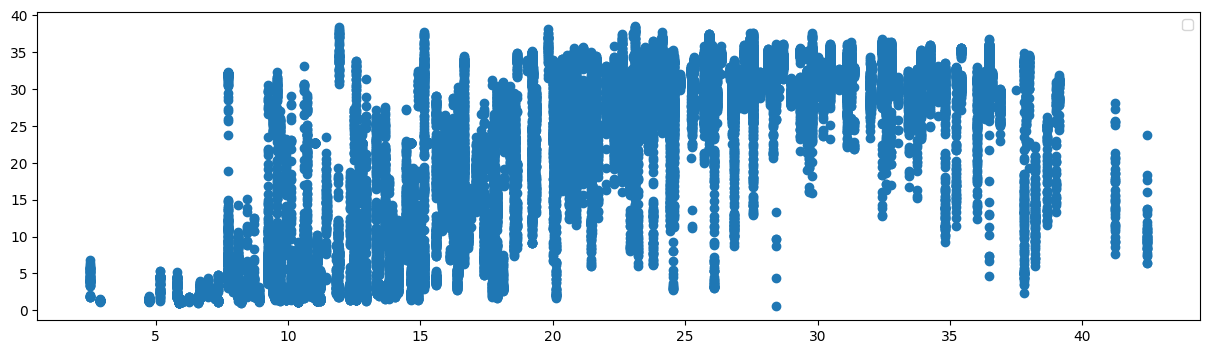

In [19]:
predictions = pipeline.predict(X_test_final)

plt.figure(figsize=(15, 4))
plt.scatter(predictions,  y_test)
plt.legend()
plt.show()


HINT: Pay special attention to this type of data: We are dealing with Time series data (i.e. data that is recorded over consistent intervals of time). It might be a good idea not to randomly split the data, since it wouldn't respect the temporal order and may cause data-leakage, unintentionally inferring the trend of future samples.

In [ ]:
# Use your preferred method to evaluate your model
### TODO -> SPLIT THE DATA INTO TRAIN AND TEST SETS, AND EVALUATE YOUR MODEL ###
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

pipeline = Pipeline(
    'model', xgb
)

tscv = TimeSeriesSplit(n_splits=5)
mae_scores = []

# Loop through the folds

for train_index, test_index in tscv.split(X):
    # Split the data based on indices
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # One-Hot Encoding (Fit on Train, Transform on Test)
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    # Process Train
    encoded_train = encoder.fit_transform(X_train[["Direction"]])
    encoded_train_df = pd.DataFrame(encoded_train, 
                                    columns=encoder.get_feature_names_out(["Direction"]), 
                                    index=X_train.index)
    
    # Process Test
    encoded_test = encoder.transform(X_test[["Direction"]])
    encoded_test_df = pd.DataFrame(encoded_test, 
                                   columns=encoder.get_feature_names_out(["Direction"]), 
                                   index=X_test.index)

    # Combine Features
    X_train_final = pd.concat([X_train[["Speed"]], encoded_train_df], axis=1)
    X_test_final = pd.concat([X_test[["Speed"]], encoded_test_df], axis=1)

    # Train and Predict
    pipeline.fit(X_train_final, y_train)
    preds = pipeline.predict(X_test_final)
    
    # Track performance
    fold_mae = mean_absolute_error(y_test, preds)
    mae_scores.append(fold_mae)
    print(f"Fold MAE: {fold_mae}")

# Final Result
print(f"Average MAE across folds: {np.mean(mae_scores)}")

Fold MAE: 5.5685553394419
Fold MAE: 7.2395941500170755
Fold MAE: 6.744155770386016
Fold MAE: 7.109618562707076
Fold MAE: 5.523030935139901
Average MAE across folds: 6.436990951538394


## Tracking your experiments with MLFlow
We have a working model with a certain accuracy. But wouldn't it be better to try different parameters and different models before deciding for one?

This is exactly what we will do using the MLFlow library. MLflow is an open source platform to manage the ML lifecycle, including experimentation, reproducibility, deployment, and a central model registry. This will allow us for easy comparison of all our model experiments.

Example
When using MLFlow locally to log our experiments, we need to start a "local server". We can do this easily by running the following in our command line interface (in the Terminal):

```
mlflow server --host 127.0.0.1 --port 5000
```

Once you start the server you will see the following information in the Terminal: `Uvicorn running on http://127.0.0.1:5000`.

The server is located at our localhost `127.0.0.1, port 5000`. We will use this information to indicate where our experiment logs will be shown.

In [14]:
# Start an MLflow run
import mlflow
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings("ignore", category=FutureWarning)


preprocessor = ColumnTransformer(
    transformers=[
        ('OHE', OneHotEncoder(handle_unknown='ignore'), ['Direction']),
        ('scale', StandardScaler(), ['Speed'])
    ]
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])


# Set the experiment and run name
experiment_name = "RF-Example" # Think how to best organise experiments - for example by model type
run_name = "RF" # Give explicit names 

# 1. Define your TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'model__n_estimators': [50, 100],          # Matches the name 'model' in your Pipeline
    'model__max_depth': [None, 2, 10],
    'model__min_samples_split': [5, 20],
    'model__bootstrap': [True, False]
}

# We pass the pipeline, the param_grid, and the tscv object
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,              # This is the key! It uses your time-series logic
    scoring='neg_mean_squared_error', # Grid search looks for the 'best' score
    n_jobs=-1             # Use all CPU cores to speed it up
)


grid_search.fit(X, y)

    # 4. Access the best results
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = -grid_search.best_score_ # Convert back to positive MSE

print(f"Best Parameters: {best_params}")
print(f"Best Mean MSE: {best_score}")

Best Parameters: {'model__bootstrap': True, 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 50}
Best Mean MSE: 51.598244785899695


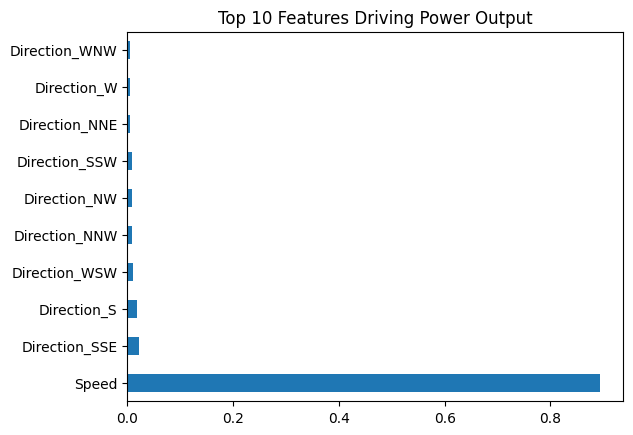

In [ ]:
ohe_features = pipeline.named_steps['preprocess'].transformers_[0][1].get_feature_names_out()
all_features = np.concatenate([ohe_features, ['Speed']])

# Get importance from the model
importances = pipeline.named_steps['model'].feature_importances_

# Plotting
feat_importances = pd.Series(importances, index=all_features)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Features Driving Power Output")
plt.show()

In [8]:
import mlflow
import warnings
from xgboost import XGBRegressor  # Swapping RF for XGB
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings("ignore", category=FutureWarning)
X = merged_df[["Speed", "Direction"]]
y = merged_df["Total"]
# 1. Preprocessing stays the same
preprocessor = ColumnTransformer(
    transformers=[
        ('OHE', OneHotEncoder(handle_unknown='ignore'), ['Direction']),
        ('scale', StandardScaler(), ['Speed'])
    ]
)

# 2. Pipeline with XGBoost
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42))
])

# 3. Define TimeSeriesSplit and XGBoost specific parameters
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [3, 6, 10],       # Depth of trees
    'model__learning_rate': [0.01, 0.1],  # "Shrinkage" to prevent overfitting
    'model__subsample': [0.8, 1.0],       # % of data used per tree
    'model__colsample_bytree': [0.8, 1.0] # % of features used per tree
}

# 4. Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X, y)

# 5. Best results
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = -grid_search.best_score_

print(f"Best XGB Parameters: {best_params}")
print(f"Best Mean MSE: {best_score}")

Best XGB Parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 50, 'model__subsample': 0.8}
Best Mean MSE: 47.77596341987508


In the example above you can see that:
- we are using `sklearn.autolog()` to automatically log `scikit-learn` specific metrics
- we set an experiment_name; if the experiment doesn't exist it will create a new one, otherwise it will use the already existent experiment
- we set a run_name; same as above
- after model training we record the MAE to compare between runs

Click on either of the links above to see your experiments. Have a look at the Overview, Model metrics, and Artifacts.

Now have a look at the *Explorer* tab on the left and notice the newly created files and folders: 
- `mlflow.db` - a database containing metadata regarding experiments, runs, and parameters that you logged
- `mlartifacts/` folders
    - each folder will correspond to a run
    - the `models` folder contains data about the logged models, such as the envinroment file, a .pkl file containing the model, and a MLmodel complete description of the model; have a look at each of those

Now try out different set-ups. You can experiment with different pre-processing steps, models, and parameters. If you need a tutorial on MLflow Tracking you can find one [here](https://mlflow.org/docs/latest/ml/tracking/).

### Comparing models

Suppose you have ran some experiments, trying different pre-processing steps, models, and parameters. To easily compare the results from our experiments, we can use the MLFlow interface.

**Example.**
We have been logging our experiments in our local server. We can access the UI by opening the localhost address in any browser. You should see a list of all the experiments under *Experiments*. When logging multiple runs with different parameters/metrics, you will be able to easily compare them using the "Chart View". Make sure to try this out.

## Registering the best model

Now suppose you have tried many different models with different parameters, you might want to register the best one. To do this, we can use again the UI. You can follow the instructions below or this [visual guide](register_model_guide.pdf) which you can open in the repository:

- In the Experiments list, select the name of the experiment you want. 
- Click Models in the left panel.
- Click on the model you want to use, in this case it's named "model"
- Then "Register Model".
- First "Select a model", click "Create New Model" and name it "LinearRegression"

Now, if you go to the Homepage, on the "Models" tab, you will see that you registered the model.

In case of doubt, you can check the [documentation](https://mlflow.org/docs/latest/ml/model-registry/tutorial/).

**Using a registered model**

Now that we have registered our best model, we can use it for future predictions. We can retrieve the weather forecasts for the next days, and make predictions of power generation.

**Example.**
First we need the new forecast data:

In [ ]:
future_df = pd.read_csv("data/future.csv")
future_df["time"] = pd.to_datetime(future_df["time"], utc=True)
future_df["Source_time"] = pd.to_datetime(future_df["Source_time"], unit="s", utc=True)

Then, we can retrieve any saved model and use it to predict on the new data:

In [ ]:
model_name = "RF_Model"
model_version = 1

model_uri = f"models:/{model_name}/{model_version}"
model = mlflow.pyfunc.load_model(model_uri=model_uri)

X_forecast = future_df[["Speed", "Direction"]]
predictions = model.predict(X_forecast)

predictions_df = future_df[["Speed"]].copy()
predictions_df["Predicted_Power"] = predictions

print(predictions_df.head())

      Speed  Predicted_Power
0  15.19936        30.859680
1  16.09344        31.167185
2  16.98752        31.260406
3  16.09344        31.525633
4  12.96416        33.757987


## Serving your model

So far, we have trained several models and registered the best one. Often times, we will want to deploy the best model in such a way that other people can take advantage of it, by sending a request with data and getting back predictions. In this project you will only serve the model locally, a step usually done before deployment to ensure that the model works as expected. 

Serving a model refers to the process of making a trained machine learning model available to receive input data and provide predictions or inferences based on that data. In other words, when you serve a model, you set it up in a way that it can be queried with new data, and it will produce predictions or outputs based on the patterns it learned during training.

Serving a model is a critical step in the machine learning lifecycle, as it allows you to leverage the model's predictive capabilities in real-world applications. When a model is served, it becomes accessible to applications, websites, or other systems that need to utilize its predictions.

You have tried serving the model in [one of the previous exercises](https://github.com/LSDA-BDM/exercise-mlflow-caiso). Run the same command to serve your current model.

> Note. The current configuration is slightly different that in the exercise. You won't have to call `mlflow run .` as in the exercise. Do you know why? However, before serving the model, you will have to set the tracking URI in the terminal with:
> ```bash
> export MLFLOW_TRACKING_URI=http://localhost:5000
> ```

Serve the model and then use `curl` to test that it worked.

## Packaging your project

Lastly, we want to make sure that others are able to run the project and do further development. As opposed to just making the model available as before (with serving) now you will package the project in order to make it reproducible.

Reproducibility refers to the ability of researchers, developers, and practitioners to recreate the exact same results, analyses, and outcomes from a given set of source code and data. In that sense, MLflow Projects is a standardized way to encapsulate an experiment in a reproducible
manner, so colleagues or other stakeholders can reproduce your code. This is done by specifying all the dependencies using a 'pip' environment file, a 'conda' environment file, or a docker environment. Here we will take the ‘pip‘ approach.

An MLflow project consists (at least) of:

- The code you want to package, including the data for your experiments (if needed). Jupyter Notebooks are not supported, so you will have to more the relevant code in `.py` file; you can check the `script.py` file provided for an example.
- A requirements.txt file specifying the dependencies for the code (in this case a text file with ‘pip‘-installable dependencies).
- An MLproject file specifying which environment file to use, parameters accepted, and the entry points to the code.

First, try to run the script `script.py` with

```bash
python script.py
```
> Note: For this to run you must have started an mlflow server as shown in Tracking your experiments.

Then, create a similar script containing your experiments; also create the other files necessary for an MLProject. Have a look at [this exercise](https://github.com/LSDA-BDM/exercise-polynomial/) that explains how MLflow projects work.

## Notes and hints

Here are a few resources you can use to inform your design decisions for your experiments:

**Joining the data.** How do you join and align the data will affect the amount of data you end up with for training your model. Make sure you explain your decision and reflect upon its pros and cons. Some resources for pandas: [Join](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html), [Merge](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html), [Resample](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html).

**Wind direction encoding.** You will most likely need to transform the wind direction into a numerical feature. Some possibilities to consider, make sure you reflect on their advantages and disadvantages:
- [OneHotEncoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- Transforming to degrees or radians with a [custom transformer](https://towardsdatascience.com/pipelines-custom-transformers-in-scikit-learn-ef792bbb3260/)
- Converting speed and direction to a [2-dimensional vector](https://www.tensorflow.org/tutorials/structured_data/time_series#wind)

**Scaling.** Think what is the range of your features. Is your model affected by this? Should you scale your features? You should explain why would you do it, or why it's not necessary. Check [Scikit-Learn's Preprocessing and Normalization](https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling) or this [article](https://www.geeksforgeeks.org/ml-feature-scaling-part-2/).

**Feature transformations.** If you want to apply different transformations to different columns (e.g. categorical and numerical), you can use the [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

**Missing values.** Check [Scikit-Learn’s imputers](https://scikit-learn.org/stable/modules/impute.html) to see different options for dealing with missing values. 

**Splitting and shuffling.** You are working with time series data. Is it acceptable to do a random shuffle on the data when splitting for training? If so, why? If not, how can you split the data? Make sure to argue your decision. Check [Scikit-Learn’s TimeSeries Split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html#sklearn.model_selection.TimeSeriesSplit) or this [article](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).

# Notes:
- The dataset is joined where the values are filled with the nearest values. Instead of inner join this way we can keep a lot more data points. The downside is that we loose the high resolution in the dataset.
- The direction is One Hot Encoded. Simple.
- Speed is standard scaled eventhough not all models need it.
- Missing values are discarded using dropna()
- Splitting is done by TimeSeriesSplit which basically acts as a cross validation fold.

The model is trained on the folds and an average mae is printed at the end along with other metrics. The model is registered after being trained on the whole dataset.  

## Workflow:

1. Parent run: Tracks the overall experiement (RF vs LR)
2. Child runs: The models, keeps LR and RF data seperated so their metrics do not overwrite each other
3. Grandchild runs: The splits, tracks the individual performance of the splits.
4. Average MSE is logged manually as well